## 선형 회귀 모델
- 원인 과 결과 사이에 비례하는 규칙이 있다고 가정하고 이를 가장 잘 나타내는 '직선'을 그어 미래를 예측하는 머신러닝 기법

### 1. 직선 방정식
- y = wx + b
    - y : 예측값
    - x : 기본값
    - w : 가중치
    - b : 편향
    
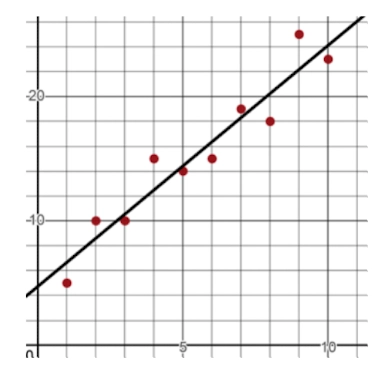

- 주어진 입력값(빨간점)과 예측값(직선)이 오차를 최소화 하는 w와 b를 찾는 과정 -> 머신러닝의 학습

### 2. 오차(Error)와 손실함수(Loss Function)
- 오차 : 계산한 모델이 실제값과 얼마나 차이가 있는지
- 손실함수 : 오차들을 모아 모델의 성능을 평가하는 공식
- 손실값 : 예측값과 실제값을 손실 함수를 통해 계산해서 나온 수치(점수)

- 평균 제곱 오차 (MSE: Mean Squared Error) : 오차를 제곱해서 더하고 평균을 낸 값
    - 제곱을 하기 때문에 예측을 크게 벗어난 값에 큰 벌점을 부여
- 평균 절대 오차 (MAE: Mean Absolute Error) : 오차를 절대값으로 변경 후 더하고 평균을 낸 값
    - 실제값과 스케일이 같기 때문에 직관적으로 볼 수 있다

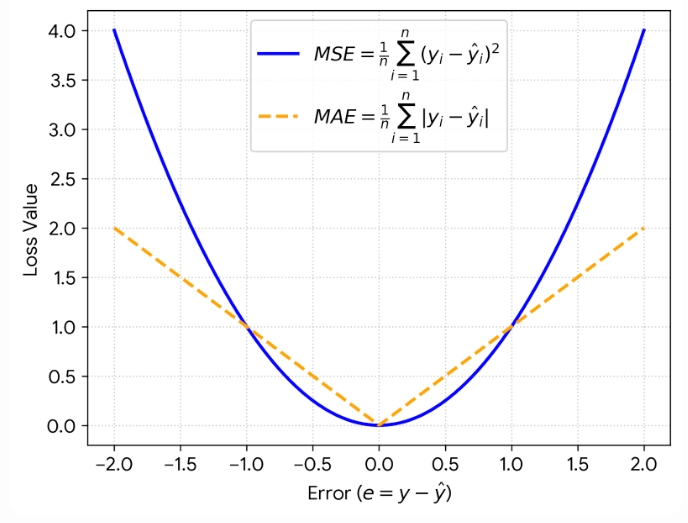

### 머신의 학습은 기울기가 0이 되는 지점을 찾아가는것에 있다

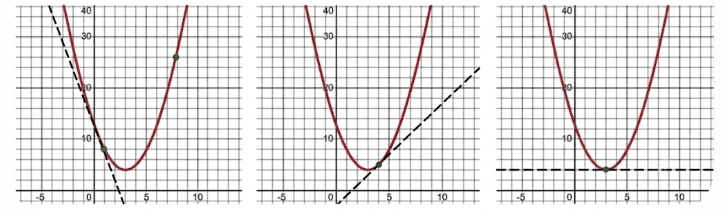

- MSE 함수 그래프에서 미분하여 기울기를 구한다 -> 현재 기울기에 따라 어느 방향으로 가야 MSE가 줄어드는지 알 수 있다 -> 기울기의 방향을 기준으로 기울기가 0이 되는 지점을 목표로 한다
- 하강 (기울기가 음수)
    - 기울기를 더하기 위해 오른쪽으로 이동시킨다
- 상승 (기울기가 양수)
    - 기울기를 빼기 위해 왼쪽으로 이동 시킨다

- --> 기울기의 반대 방향으로 이동

$$
w_{new}=w_{old}-\alpha\cdot\frac{\partial J}{\partial w}
$$
- $w_{new}$**(새로운 위치)**: 다음번에 인공지능이 발을 디딜 새로운 좌표(업데이트된 가중치)입니다.
- $w_{old}$ **(현재 위치)**: 지금 인공지능이 서 있는 현재 좌표(현재의 가중치)입니다.
- $\alpha$ **(학습률, Learning Rate)**: 한 번에 얼마나 크게 걸음을 내디딜지 결정하는 '보폭'입니다.
- $\frac{\partial J}{\partial w}$**(기울기, Gradient)**: 현재 위치에서 느껴지는 '땅의 가파른 정도(경사)'입니다.

$\frac{\partial J}{\partial w}$ **전체가 의미하는 것**

---

한마디로 "가중치 $w$를 아주 미세하게 변화시켰을 때, 전체 오차 $J$가 얼마나 변화하는가?"를 나타내는 순간 변화율(기울기, Gradient)입니다.

이 값은 모델 학습에서 두 가지 결정적인 힌트를 제공합니다.

1. ***오차를 줄이기 위해 가중치를 움직여야 하는 '방향’***


$\frac{\partial J}{\partial w} >0 $ **(양수 코너)**: $w$가 커질 때 오차 $J$도 커진다는 뜻입니다. 따라서 오차를 줄이려면 $w$를 **감소**시켜야 합니다.

$\frac{\partial J}{\partial w} < 0$ (음수 코너): $w$가 커질 때 오차 $J$가 작아진다는 뜻입니다. 따라서 오차를 줄이려면 $w$를 **증가**시켜야 합니다.

- 현재 위치 - 학습률 X 기울기 인 이유 
    - 기울기가 양수 일때 W가 커지면 오차도 커짐 (기울기가 양수니까) 오차를 줄이려면 감소(-(+) = -)
    - 기울기가 음수 일때 W가 작아지면 오차가 커짐 (기울기가 음수니까) 오차를 줄이려면 증가(-(-) = +)



In [ ]:
# 스포티파이 관련 데이터셋으로 선형 회귀 모델과 오차 평가 지표 해보기
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../../dataset.csv')
df.head()

In [ ]:
# 해볼 모델 -> tempo 와 popularity 해당 데이터 그래프 그리기

df = df[df['popularity'] > 90]

plt.figure(figsize=(5,5))
plt.scatter(df['popularity'],df['tempo'], color='blue')
plt.title('popularity - tempo')
plt.xlabel('popularity')
plt.ylabel('tempo')

In [ ]:
# 모델 학습 및 결과 시각화
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

x = df[['popularity']]
y = df['tempo']

x.shape, y.shape # 학습할 모델의 데이터 개수 확인용 x(입력) 과 y(결과) 가 같은 수여야 한다

In [ ]:
model = LinearRegression() # 선형 회귀 모델 준비
model.fit(x,y); # x,y 데이터로 학습, unicode 문제 발생시 ; 입력

print(model.coef_, model.intercept_) # 기울기 w 와 편향 b

y_pred = model.predict(x) # 입력값 x 에 대한 y 예측값을 계산하여 y_pred에 넣기

In [ ]:
mse = mean_squared_error(y,y_pred)
mae = mean_absolute_error(y,y_pred)

print(mse,mae) # 오차값을 확인

In [ ]:
# 모델의 직선 그래프와 실제 값의 차이를 그래프로 그려보기

plt.figure(figsize=(5,5))
plt.scatter(x,y, color='blue',label='real') # 선점도로 파란 색상의 점을 찍는다
plt.plot(x,y_pred,color='red', label='predict') # 직선 그래프로 빨간 선을 긋는다
plt.title('Linear Model popularity - tempo')
plt.xlabel('popularity')
plt.ylabel('tempo')
plt.legend()
plt.show()

In [ ]:
df = pd.read_csv('../../dataset.csv')

#df.info()

df = df[df['popularity'] > 90]

x = df[['tempo','danceability','energy']]
y = df['popularity']

model.fit(x,y)

y_pred = model.predict(x)

x.shape, y.shape

In [ ]:
plt.figure(figsize=(10,10))
plt.scatter(x,y,color='blue',label='real')
plt.plot(x,y_pred,color='red',label='pred')

# 2개 이상은 그냥 할 수 없다... x가 2개면 3차원 이 필요하고 3개 부터는 표현하기 어렵다